KPIs:

1. LOS hospitalizado

2. LOS en lista de espera

3. Costo diario promedio (social y operativo)

4. Costo de desvíos a clínicas (operativo)

5. Costo de traslados entre hospitales (operativo)

6. Costo promedio por paciente (social mas operativo)

7. Tasa de entrada vs tasa de salida (entrada wl y ed, salida sdu o ps)

8. Tasa de ocupación de camas (grafico)


1. Average LOS

2. Average LOS by hospital

3. Average LOS by unit

4. Average LOS by DRG

5. Total Cost of Derivation

6. Average Daily Cost of Derivation

7. Percentage of Patients Derived to Private System

8. Occupancy Rate

In [43]:
# Librerias necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import parametros as p

In [44]:
# Funciones necesarias para preprocesamiento de datos
def agregar_filas_intermedias(df, escala):
    tl = df.copy()
    tiene_requerimiento_inicial = "requerimiento_inicial" in tl.columns

    def add_event_order(df):
        if "orden" not in df.columns:
            df = df.copy()
            df["orden"] = df.groupby("ID").cumcount() + 1
        return df
    
    # Agrego orden de eventos
    tl = add_event_order(tl)

    tl.sort_values(by=["ID", "orden"], inplace=True)
    if escala != 12:
        tl["TI"] = tl["TI"]*12
        tl["TF"] = tl["TF"]*12

    # Agrego LOS a cada fila y reordeno
    tl["LOS"] = (tl["TF"] - tl["TI"])
    if tiene_requerimiento_inicial:
        tl = tl[["ID", "MS_GRD", "UBICACIÓN", "TI", "TF", "LOS", "HOSPITAL", "UNIDAD", "orden", "requerimiento_inicial"]]
    else:
        tl = tl[["ID", "MS_GRD", "UBICACIÓN", "TI", "TF", "LOS", "HOSPITAL", "UNIDAD", "orden"]]

    # Lista para guardar filas nuevas
    new_rows = []

    # Recorrer filas consecutivas
    for i in range(len(tl) - 1):
        row_current = tl.iloc[i]
        row_next = tl.iloc[i + 1]

        # Verificar condiciones
        same_id = row_current['ID'] == row_next['ID']
        same_ms = row_current['MS_GRD'] == row_next['MS_GRD']
        time_gap = row_current['TF'] < row_next['TI']
        time_gap_cero = row_current['TF'] == row_next['TI']
        same_hospital = row_current['HOSPITAL'] == row_next['HOSPITAL']
        
        if tiene_requerimiento_inicial:
            if same_id and same_ms and time_gap:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': row_current['UNIDAD'],
                    'orden': row_current['orden'] + 0.1,  # Ajustar el orden
                    'requerimiento_inicial': row_current['requerimiento_inicial']
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción
            
            if same_id and same_ms and time_gap_cero and not same_hospital:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': "En movimiento",
                    'orden': row_current['orden'] + 0.1,  # Ajustar el orden
                    'requerimiento_inicial': row_current['requerimiento_inicial']
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción
        else:
            if same_id and same_ms and time_gap:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': row_current['UNIDAD'],
                    'orden': row_current['orden'] + 0.1  # Ajustar el orden
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción
            
            if same_id and same_ms and time_gap_cero and not same_hospital:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': "En movimiento",
                    'orden': row_current['orden'] + 0.1  # Ajustar el orden
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción

    # Lista para guardar todas las filas nuevas (dicts)
    new_rows_list = [fila[1] for fila in new_rows]

    # Convertir todo a un DataFrame una sola vez
    new_rows_df = pd.DataFrame(new_rows_list)

    # Concatenar en una sola pasada
    tl = pd.concat([tl, new_rows_df], ignore_index=True)

    # Reordenar filas para meter filas entremedio
    tl = tl.sort_values(by=["ID", "orden"])

    # Resetear index para que se vea ordenado
    tl_1 = tl.reset_index(drop=True)

    # Ya ordenado elimino la columna orden
    tl_1.drop(columns=["orden"], inplace=True)

    return tl_1

def add_operational_costs(df):
    df = df.copy()  # avoid mutating original

    # Define transfer transitions
    traslados = {
        'Hospital_1_ED -> Hospital_2_ED',
        'Hospital_1_ED -> Hospital_3_ED',
        'Hospital_2_ED -> Hospital_1_ED',
        'Hospital_2_ED -> Hospital_3_ED',
        'Hospital_3_ED -> Hospital_1_ED',
        'Hospital_3_ED -> Hospital_2_ED'
    }

    # Costo DER WL
    if 'requerimiento_inicial' in df.columns:
        df["COSTO DER WL"] = df.apply(
            lambda x: p.dict_costo_derivar_wl[x["MS_GRD"]][x["requerimiento_inicial"]]
            if x["UBICACIÓN"] == "WL_WL -> PS_PS" else 0,
            axis=1
        )
    else:
        df["COSTO DER WL"] = df.apply(
            lambda x: (
                sum(p.dict_costo_derivar_wl[x["MS_GRD"]][u] for u in [1, 2, 3]) / 3
                if x["UBICACIÓN"] == "WL_WL -> PS_PS" else 0
            ),
            axis=1
        )

    # Costo DER ED
    if 'requerimiento_inicial' in df.columns:
        df["COSTO DER ED"] = df.apply(
            lambda x: p.dict_costo_derivar_ed[p.dict_hospitales[x["HOSPITAL"]]][x["MS_GRD"]][x["requerimiento_inicial"]]
            if x["UBICACIÓN"] == f"{x['HOSPITAL']}_ED -> PS_PS" else 0,
            axis=1
        )
    else:
        df["COSTO DER ED"] = df.apply(
            lambda x: (
                sum(p.dict_costo_derivar_ed[p.dict_hospitales[x["HOSPITAL"]]][x["MS_GRD"]][u] for u in [1, 2, 3]) / 3
                if x["UBICACIÓN"] == f"{x['HOSPITAL']}_ED -> PS_PS" else 0
            ),
            axis=1
        )

    # Costo TRASLADO
    def parse_hospital_number(hospital_str):
        return int(hospital_str.split("_")[1])

    if 'requerimiento_inicial' in df.columns:
        df["COSTO TRASLADO"] = df.apply(
            lambda x: (
                p.dict_costo_traslado[
                    parse_hospital_number(x["UBICACIÓN"].split(" -> ")[0])
                ][
                    parse_hospital_number(x["UBICACIÓN"].split(" -> ")[1])
                ][x["MS_GRD"]][
                    x["requerimiento_inicial"]
                ]
                if x["UBICACIÓN"] in traslados else 0
            ),
            axis=1
        )
    else:
        def costo_promedio_traslado(x):
            if x["UBICACIÓN"] not in traslados:
                return 0
            h1 = parse_hospital_number(x["UBICACIÓN"].split(" -> ")[0])
            h2 = parse_hospital_number(x["UBICACIÓN"].split(" -> ")[1])
            costos = [p.dict_costo_traslado[h1][h2][x["MS_GRD"]][u] for u in [1, 2, 3]]
            return sum(costos) / 3

        df["COSTO TRASLADO"] = df.apply(costo_promedio_traslado, axis=1)
        
        

    return df

def add_waiting_costs(df):
    df = df.copy()

    def calcular_costo_espera(row):
        drg = row["MS_GRD"]
        los = row["LOS"] / 12 # Convertir a ciclos
        unidad = row.get("requerimiento_inicial", None)
        ubicacion = row["UBICACIÓN"]
        hospital_nombre = row["HOSPITAL"]
        hospital = p.dict_hospitales.get(hospital_nombre)

        # 1. Paciente en WL_WL (esperando en lista)
        if row["HOSPITAL"] == "WL" and ubicacion == "WL_WL":
            if unidad is not None:
                return p.dict_costo_espera_wl[drg][unidad] * los
            else:
                costos = [p.dict_costo_espera_wl[drg][u] for u in [1, 2, 3]]
                return sum(costos) / 3 * los

        # 2. Paciente en GA o ED con LOS > 0
        elif row["UNIDAD"] in {"GA", "ED"} and los > 0:
            source = p.dict_costo_espera_ga if row["UNIDAD"] == "GA" else p.dict_costo_espera_ed
            if unidad is not None:
                return source[hospital][drg][unidad] * los
            else:
                costos = [source[hospital][drg][u] for u in [1, 2, 3]]
                return sum(costos) / 3 * los

        # 3. Paciente hospitalizado y bloqueado
        elif row["UNIDAD"] in {"OR", "ICU", "SDU_WARD"} and "->" in ubicacion and los > 0:
            try:
                origen_str, destino_str = ubicacion.split(" -> ")
                unidad_actual = "_".join(origen_str.split("_")[2:])
                unidad_requerida = "_".join(destino_str.split("_")[2:])
                return p.dict_costo_espera_hospitalizado[hospital][drg][p.dict_unidades[unidad_actual]][p.dict_unidades[unidad_requerida]] * los
            except Exception:
                return 0  # fallback in case of malformed UBICACION
        return 0

    df["COSTO ESPERA"] = df.apply(calcular_costo_espera, axis=1)
    return df

In [45]:
# ldf = pd.read_csv("log original/log original.csv", sep=",")
sdf = pd.read_csv("resultados simulacion/modelo_base_a_mi_modelo.csv", sep=",")

# Agregar filas intermedias
# ldf = agregar_filas_intermedias(ldf, 12)
sdf = agregar_filas_intermedias(sdf, 1)

# Agregar costos operacionales
# ldf = add_operational_costs(ldf)
sdf = add_operational_costs(sdf)

# Agregar costos de espera
# ldf = add_waiting_costs(ldf)
sdf = add_waiting_costs(sdf)

# Para no tener que correr lo de arriba cada vez, guardo los resultados
# ldf.to_csv("resultados modificados/log_original.csv", index=False)
sdf.to_csv("resultados modificados/log_simulacion.csv", index=False)

In [46]:
ldf = pd.read_csv("resultados modificados/log_original.csv", sep=",")
sdf = pd.read_csv("resultados modificados/log_simulacion.csv", sep=",")

In [47]:
def filter_by_patient_activity_period(df, start_time=10000, end_time=40000):
    """
    Filters a DataFrame to include only patients who were active (TI–TF overlap)
    during a specified time window.
    """
    if start_time is None and end_time is None:
        return df

    condition = pd.Series(True, index=df.index)
    if start_time is not None:
        condition &= df['TF'] >= start_time
    if end_time is not None:
        condition &= df['TI'] <= end_time

    valid_ids = df[condition]['ID'].unique()
    return df[df['ID'].isin(valid_ids)]

# 1. LOS hospitalizado
def compute_los_hospitalizado(df, start_time=10000, end_time=40000):
    valid_units = ['GA', 'ED', 'OR', 'ICU', 'SDU_WARD']
    hospitals = ['Hospital_1', 'Hospital_2', 'Hospital_3']

    # Step 0: Exclude patients who ever entered PS
    ps_patients = df[df['UNIDAD'] == 'PS']['ID'].unique()

    # Step 0: Base filtering — keep only relevant units and hospitals, and exclude PS patients
    df_filtered = df[
        (df['HOSPITAL'].isin(hospitals)) &
        (df['UNIDAD'].isin(valid_units)) &
        (~df['ID'].isin(ps_patients))
    ]

    # Step 1: Base filtering — keep only relevant hospital units
    df_filtered = df[
        (df['HOSPITAL'].isin(hospitals)) &
        (df['UNIDAD'].isin(valid_units))
    ]

    # Step 2: Identify patients active within the time window
    df_filtered = filter_by_patient_activity_period(df_filtered, start_time, end_time)

    # Step 3: Calculate averages

    # LOS per hospital and unit
    los_by_hospital_unit = (
        df_filtered
        .groupby(['HOSPITAL', 'UNIDAD'])['LOS']
        .mean()
        .round(2)
        .unstack(fill_value=None)
        .to_dict(orient='index')
    )

    # Step 1: sum LOS per patient per hospital
    patient_los = (
        df_filtered
        .groupby(['ID', 'HOSPITAL'])['LOS']
        .sum()
        .reset_index()
    )

    # Step 2: average across patients per hospital
    los_by_hospital = (
        patient_los
        .groupby('HOSPITAL')['LOS']
        .mean()
        .round(2)
        .to_dict()
    )

    # LOS per unit (across all hospitals)
    los_by_unit = (
        df_filtered
        .groupby('UNIDAD')['LOS']
        .mean()
        .round(2)
        .to_dict()
    )

    return {
        "por_hospital_y_unidad": los_by_hospital_unit,
        "promedio_por_hospital": los_by_hospital,
        "promedio_por_unidad": los_by_unit
    }

# 2. LOS en lista de espera
def compute_los_lista_espera_total(df, start_time=10000, end_time=40000):
    # Step 1: filter only rows where patient is in WL
    df_filtered = df[df['UNIDAD'] == 'WL']

    # Step 2: filter by activity between start_time and end_time
    df_filtered = filter_by_patient_activity_period(df_filtered, start_time, end_time)

    # Step 3: sum LOS in WL per patient
    los_by_patient = df_filtered.groupby('ID')['LOS'].sum()

    # Step 4: compute and return the average LOS
    return round(los_by_patient.mean(), 2) if not los_by_patient.empty else None

# 3. Costos
def compute_costo_diario_promedio(df, start_time=10000, end_time=40000):
    df = df.copy()

    # Filter by patient activity during the specified period
    df = filter_by_patient_activity_period(df, start_time, end_time)

    # Total time in hours
    total_hours = (end_time - start_time) if start_time is not None and end_time is not None else df["TF"].max() - df["TI"].min()
    
    ciclos = int(total_hours // 12)  # Integer number of 12-hour cycles
    if ciclos == 0:
        return {
            "social": 0, "derivaciones_wl": 0, "derivaciones_ed": 0,
            "traslados": 0, "operativo": 0, "total": 0
        }

    # Individual cost components
    costo_social = df["COSTO ESPERA"].sum()
    costo_wl = df["COSTO DER WL"].sum()
    costo_ed = df["COSTO DER ED"].sum()
    costo_traslados = df["COSTO TRASLADO"].sum()

    # Compute average cost per 12-hour cycle
    return {
        "social": round(costo_social / ciclos, 2),
        "derivaciones_wl": round(costo_wl / ciclos, 2),
        "derivaciones_ed": round(costo_ed / ciclos, 2),
        "traslados": round(costo_traslados / ciclos, 2),
        "operativo": round((costo_wl + costo_ed + costo_traslados) / ciclos, 2),
        "total": round((costo_social + costo_wl + costo_ed + costo_traslados) / ciclos, 2)
    }

# 4. Costo promedio por paciente
def compute_costo_promedio_paciente(df, start_time=10000, end_time=40000):
    df = df.copy()
    df = filter_by_patient_activity_period(df, start_time, end_time)

    total_pacientes = df["ID"].nunique()
    if total_pacientes == 0:
        return {
            "costo_social_promedio": 0,
            "costo_operativo_promedio": 0,
            "costo_total_promedio": 0
        }

    costo_social = df["COSTO ESPERA"].sum()
    costo_operativo = (
        df["COSTO DER WL"].sum() +
        df["COSTO DER ED"].sum() +
        df["COSTO TRASLADO"].sum()
    )

    return {
        "costo_social_promedio": round(costo_social / total_pacientes, 2),
        "costo_operativo_promedio": round(costo_operativo / total_pacientes, 2),
        "costo_total_promedio": round((costo_social + costo_operativo) / total_pacientes, 2)
    }

# 5. Tasas de entrada y salida
def compute_tasa_entrada_vs_salida(df, start_time=10000, end_time=40000):
    df = df.copy()
    df = filter_by_patient_activity_period(df, start_time, end_time)

    # Total time in 12-hour cycles
    total_hours = (end_time - start_time) if start_time is not None and end_time is not None else df["TF"].max() - df["TI"].min()
    ciclos = int(total_hours // 12)
    if ciclos == 0:
        return {
            "entradas_wl_por_ciclo": 0,
            "entradas_ed_por_ciclo": 0,
            "total_entradas_por_ciclo": 0,
            "salidas_ps_por_ciclo": 0,
            "salidas_sdu_por_ciclo": 0,
            "total_salidas_por_ciclo": 0,
            "ratio_salida_entrada": 0,
            "ratio_salida_entrada_sin_ps": 0
        }

    # First and last row per patient
    first_rows = df.groupby("ID").first()
    last_rows = df.groupby("ID").last()

    # Entradas
    entradas_wl = (first_rows["HOSPITAL"] == "WL").sum()
    entradas_ed = (first_rows["UNIDAD"] == "ED").sum()
    total_entradas = entradas_wl + entradas_ed

    # Salidas
    salidas_ps = (last_rows["UNIDAD"] == "PS").sum()
    salidas_sdu = (last_rows["UNIDAD"] == "SDU_WARD").sum()
    total_salidas = salidas_ps + salidas_sdu

    # Normalize everything per cycle
    return {
        "entradas_wl_por_ciclo": round(entradas_wl / ciclos, 2),
        "entradas_ed_por_ciclo": round(entradas_ed / ciclos, 2),
        "total_entradas_por_ciclo": round(total_entradas / ciclos, 2),
        "salidas_ps_por_ciclo": round(salidas_ps / ciclos, 2),
        "salidas_sdu_por_ciclo": round(salidas_sdu / ciclos, 2),
        "total_salidas_por_ciclo": round(total_salidas / ciclos, 2),
        "ratio_salida_entrada": round(total_salidas / total_entradas, 2) if total_entradas > 0 else 0,
        "ratio_salida_entrada_sin_ps": round(salidas_sdu / total_entradas, 2) if total_entradas > 0 else 0
    }

# 6. Tasa de ocupación de camas
def unit_counts_all_hospitals(tl, T_max, hospitals, show_wl=True, stable_start=10000, stable_end=40000, grid=False):
    step = 6
    times = np.arange(18, T_max + 1, step)  # Midpoint time steps
    ti = tl["TI"].values
    tf = tl["TF"].values
    ub = tl["UNIDAD"]
    hs = tl["HOSPITAL"]

    i_start = stable_start // step
    i_end = stable_end // step

    plot_data = []

    # WL data
    if show_wl:
        wl_mask = ub.str.contains("WL").values
        starts = ti[wl_mask] // step
        ends = tf[wl_mask] // step
        wl_counts = np.zeros(len(times), dtype=int)
        for s, e in zip(starts, ends):
            wl_counts[s:min(e, len(times))] += 1
        avg_wl = np.mean(wl_counts[i_start:i_end])
        std_wl = np.std(wl_counts[i_start:i_end])
        plot_data.append(("WL", wl_counts, [("WL", avg_wl, std_wl)]))

    # Hospital data
    for hospital in hospitals:
        or_mask = (ub == "OR") & (hs == hospital)
        icu_mask = (ub == "ICU") & (hs == hospital)
        sdu_mask = (ub.str.contains("SDU") | ub.str.contains("WARD")) & (hs == hospital)
        ed_mask = (ub == "ED") & (hs == hospital)
        ga_mask = (ub == "GA") & (hs == hospital)

        def count(mask):
            starts = ti[mask] // step
            ends = tf[mask] // step
            counts = np.zeros(len(times), dtype=int)
            for s, e in zip(starts, ends):
                counts[s:min(e, len(times))] += 1
            return counts

        or_counts = count(or_mask)
        icu_counts = count(icu_mask)
        sdu_counts = count(sdu_mask)
        ed_counts = count(ed_mask)
        ga_counts = count(ga_mask)

        # Map counts and stats by label
        unit_data = {
            "SDU/WARD": (sdu_counts, np.mean(sdu_counts[i_start:i_end]), np.std(sdu_counts[i_start:i_end])),
            "ICU": (icu_counts, np.mean(icu_counts[i_start:i_end]), np.std(icu_counts[i_start:i_end])),
            "GA": (ga_counts, np.mean(ga_counts[i_start:i_end]), np.std(ga_counts[i_start:i_end])),
            "OR": (or_counts, np.mean(or_counts[i_start:i_end]), np.std(or_counts[i_start:i_end])),
            "ED": (ed_counts, np.mean(ed_counts[i_start:i_end]), np.std(ed_counts[i_start:i_end]))
        }

        legend_order = ["SDU/WARD", "ICU", "GA", "OR", "ED"]
        ordered_counts = [unit_data[u][0] for u in legend_order]
        ordered_labels = [(u, unit_data[u][1], unit_data[u][2]) for u in legend_order]

        plot_data.append((hospital, ordered_counts, ordered_labels))

    # Plotting
    if grid:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
        axes = axes.flatten()

        for idx, (title, counts, labels) in enumerate(plot_data):
            ax = axes[idx]
            if title == "WL":
                ax.plot(times, counts, label=f"{labels[0][0]} (avg={labels[0][1]:.2f}±{labels[0][2]:.2f})", color="black")
            else:
                for unit_counts, (label, avg, std) in zip(counts, labels):
                    ax.plot(times, unit_counts, label=f"{label} (avg={avg:.2f}±{std:.2f})")
            ax.axvspan(stable_start, stable_end, color='gray', alpha=0.2)
            ax.set_title(title)
            ax.set_ylabel("Personas")
            ax.grid(True)
            ax.legend(loc='center', bbox_to_anchor=(0.5, 0.6))

        for i in range(len(plot_data), 4):
            fig.delaxes(axes[i])

        fig.supxlabel("Horas")
        plt.tight_layout()
        plt.show()

    else:
        for title, counts, labels in plot_data:
            plt.figure(figsize=(10, 5))
            if title == "WL":
                plt.plot(times, counts, label=f"{labels[0][0]} (avg={labels[0][1]:.2f}±{labels[0][2]:.2f})", color="black")
            else:
                for unit_counts, (label, avg, std) in zip(counts, labels):
                    plt.plot(times, unit_counts, label=f"{label} (avg={avg:.2f}±{std:.2f})")
            plt.axvspan(stable_start, stable_end, color="gray", alpha=0.2)
            plt.title(title)
            plt.xlabel("Horas")
            plt.ylabel("Personas")
            plt.grid(True)
            plt.legend(loc='center', bbox_to_anchor=(0.5, 0.6))
            plt.tight_layout()
            plt.show()

In [48]:
kpis_ldf = {}
kpis_sdf = {}

In [49]:
# Calcular KPIs original
kpis_ldf["LOS_hospitalizado"] = compute_los_hospitalizado(ldf)
kpis_ldf["LOS_lista_espera"] = compute_los_lista_espera_total(ldf)
kpis_ldf["costo_diario_promedio"] = compute_costo_diario_promedio(ldf)
kpis_ldf["costo_promedio_paciente"] = compute_costo_promedio_paciente(ldf)
kpis_ldf["tasa_entrada_vs_salida"] = compute_tasa_entrada_vs_salida(ldf)

# Calcular KPIs simulación
kpis_sdf["LOS_hospitalizado"] = compute_los_hospitalizado(sdf)
kpis_sdf["LOS_lista_espera"] = compute_los_lista_espera_total(sdf)
kpis_sdf["costo_diario_promedio"] = compute_costo_diario_promedio(sdf)
kpis_sdf["costo_promedio_paciente"] = compute_costo_promedio_paciente(sdf)
kpis_sdf["tasa_entrada_vs_salida"] = compute_tasa_entrada_vs_salida(sdf)


In [50]:
display(kpis_ldf, kpis_sdf)

{'LOS_hospitalizado': {'por_hospital_y_unidad': {'Hospital_1': {'ED': 0.09,
    'GA': 36.28,
    'ICU': 66.86,
    'OR': 13.47,
    'SDU_WARD': 207.46},
   'Hospital_2': {'ED': 0.0,
    'GA': 40.24,
    'ICU': 64.06,
    'OR': 13.41,
    'SDU_WARD': 199.49},
   'Hospital_3': {'ED': 0.03,
    'GA': 49.3,
    'ICU': 67.54,
    'OR': 13.69,
    'SDU_WARD': 208.33}},
  'promedio_por_hospital': {'Hospital_1': 264.29,
   'Hospital_2': 290.97,
   'Hospital_3': 290.08},
  'promedio_por_unidad': {'ED': 0.04,
   'GA': 41.6,
   'ICU': 66.12,
   'OR': 13.52,
   'SDU_WARD': 205.02}},
 'LOS_lista_espera': 846.38,
 'costo_diario_promedio': {'social': 21317.46,
  'derivaciones_wl': 2495.8,
  'derivaciones_ed': 698.35,
  'traslados': 129.15,
  'operativo': 3323.3,
  'total': 24640.77},
 'costo_promedio_paciente': {'costo_social_promedio': 666.68,
  'costo_operativo_promedio': 103.93,
  'costo_total_promedio': 770.61},
 'tasa_entrada_vs_salida': {'entradas_wl_por_ciclo': 16.17,
  'entradas_ed_por_ciclo'

{'LOS_hospitalizado': {'por_hospital_y_unidad': {'Hospital_1': {'ED': 0.0,
    'GA': 11.84,
    'ICU': 67.79,
    'OR': 13.82,
    'SDU_WARD': 195.55},
   'Hospital_2': {'ED': 0.0,
    'GA': 7.8,
    'ICU': 63.28,
    'OR': 13.6,
    'SDU_WARD': 186.14},
   'Hospital_3': {'ED': 0.0,
    'GA': 17.47,
    'ICU': 66.47,
    'OR': 13.64,
    'SDU_WARD': 192.68}},
  'promedio_por_hospital': {'Hospital_1': 249.53,
   'Hospital_2': 258.1,
   'Hospital_3': 260.76},
  'promedio_por_unidad': {'ED': 0.0,
   'GA': 12.21,
   'ICU': 65.81,
   'OR': 13.69,
   'SDU_WARD': 191.38}},
 'LOS_lista_espera': 798.35,
 'costo_diario_promedio': {'social': 9081.27,
  'derivaciones_wl': 225.74,
  'derivaciones_ed': 2677.78,
  'traslados': 87.55,
  'operativo': 2991.07,
  'total': 12072.34},
 'costo_promedio_paciente': {'costo_social_promedio': 284.02,
  'costo_operativo_promedio': 93.55,
  'costo_total_promedio': 377.57},
 'tasa_entrada_vs_salida': {'entradas_wl_por_ciclo': 16.17,
  'entradas_ed_por_ciclo': 15.8

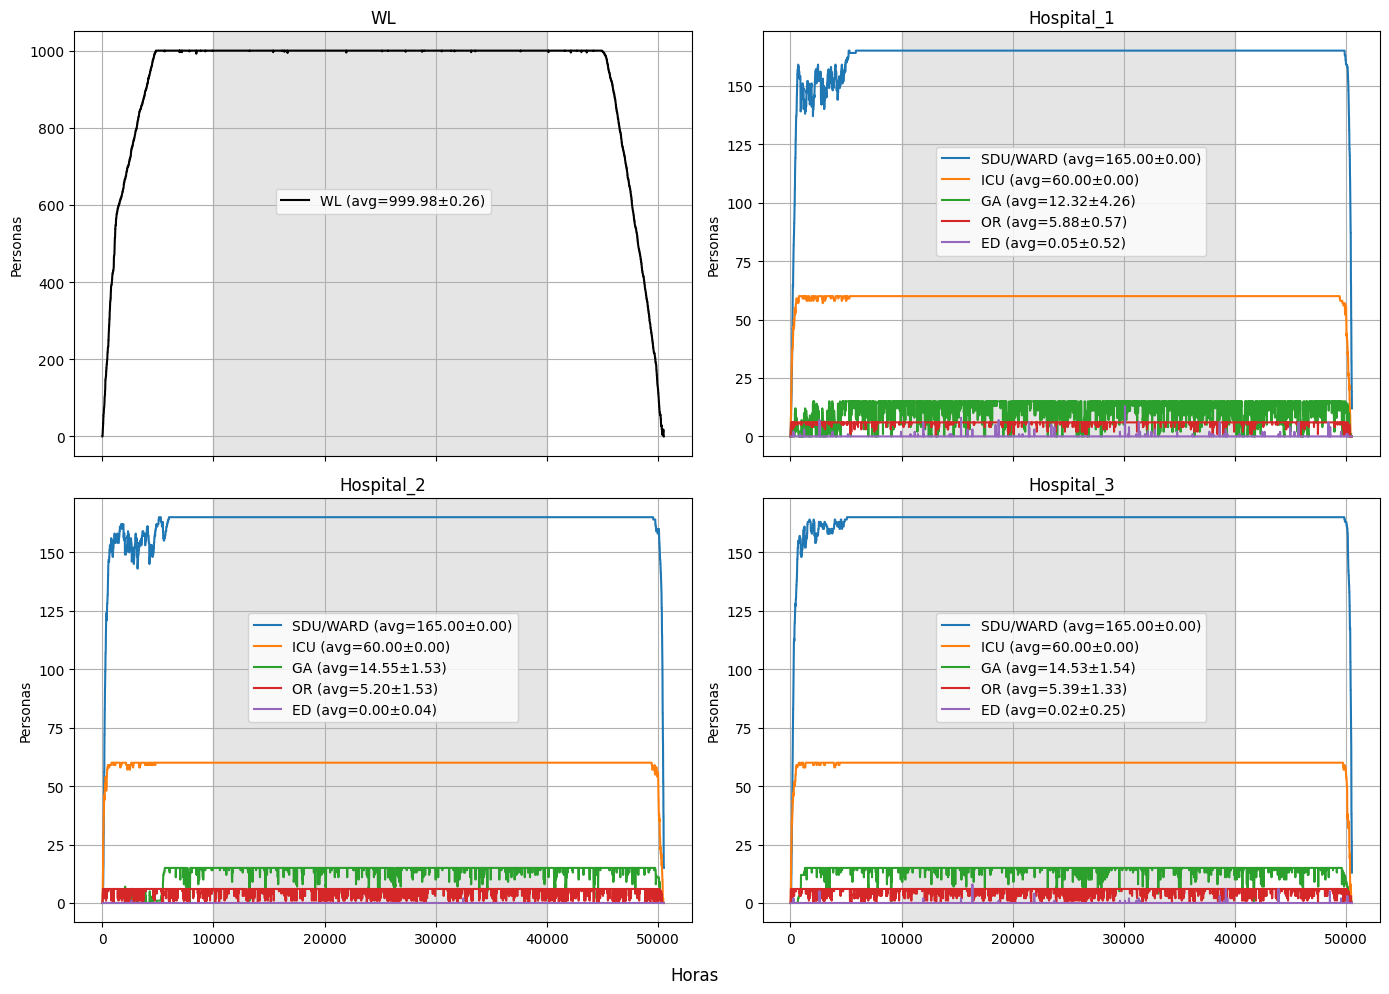

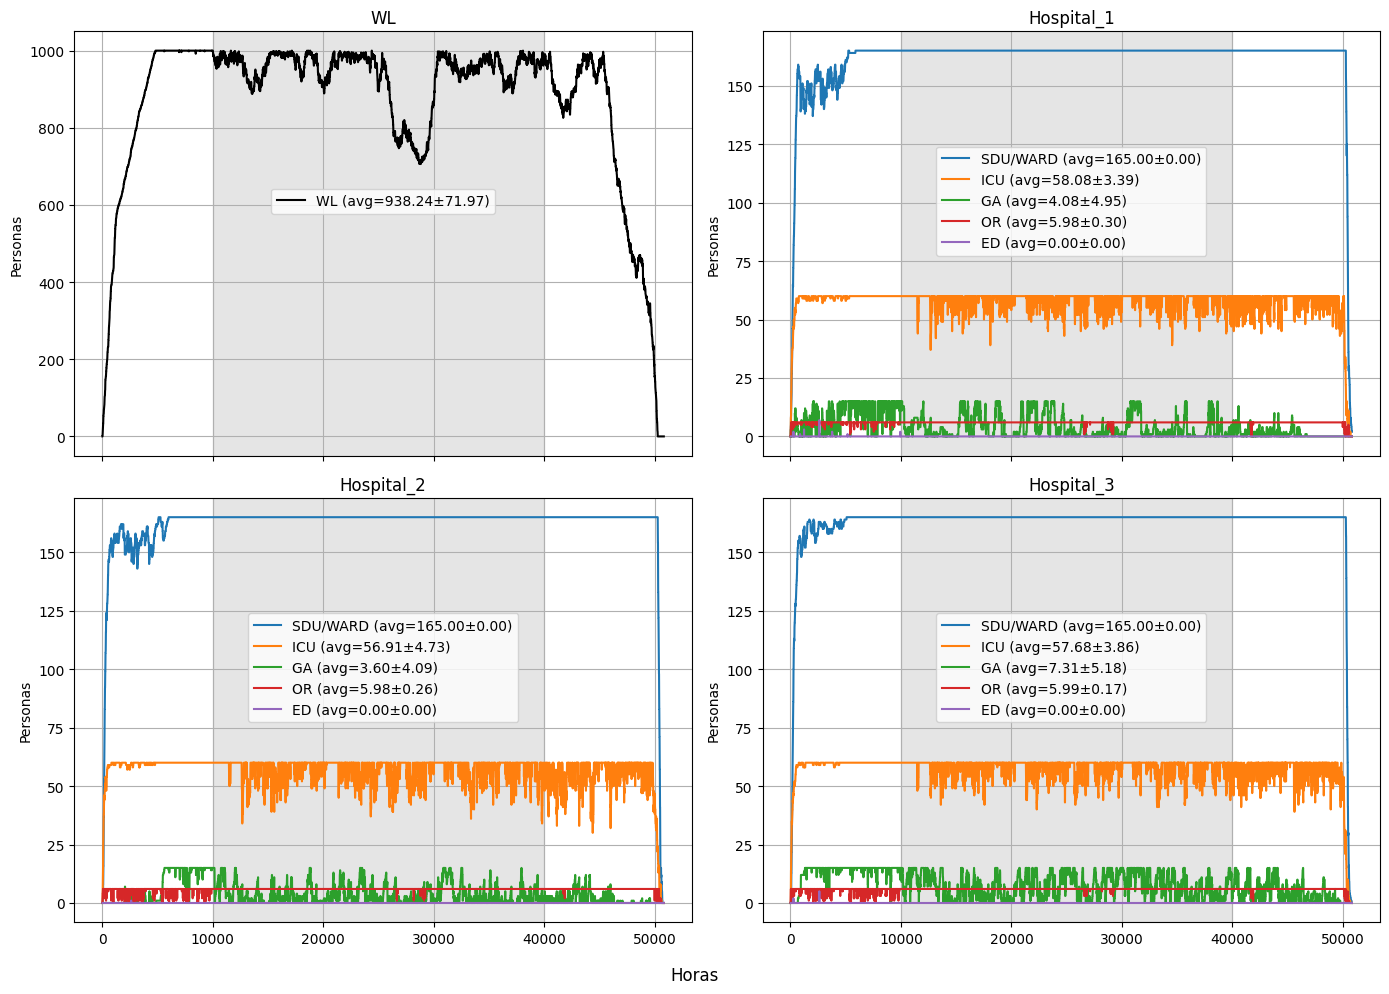

In [51]:
unit_counts_all_hospitals(
    ldf,
    T_max=ldf["TF"].max(),
    hospitals=["Hospital_1", "Hospital_2", "Hospital_3"],
    show_wl=True,
    stable_start=10000,
    stable_end=40000,
    grid=True  # → plots all in a 2x2 layout
)

unit_counts_all_hospitals(
    sdf,
    T_max=sdf["TF"].max(),
    hospitals=["Hospital_1", "Hospital_2", "Hospital_3"],
    show_wl=True,
    stable_start=10000,
    stable_end=40000,
    grid=True  # → plots all in a 2x2 layout
)